## Title: Part 2
## Author: Laven_240730653
## Date: 2026-03-15

### Questions:

#### a) What are the best times and days of the week to minimise delays each year?
#### b) Evaluate whether older planes suffer more delays on a year-to-year basis.
#### c) For each year, fit a logistic regression model for the probability of diverted US flights using as many features as possible from attributes of the departure date, the scheduled departure and arrival times, the coordinates and distance between departure and planned arrival airports, and the carrier. Visualize the coefficients across years.

In [49]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

### Import Libraries and Load 2004–2008 Dataset
define columns needed to save time: loads 15 columns instead of all 29

In [2]:

years = [2004, 2005, 2006, 2007, 2008]

cols_needed = ["Year", "Month", "DayOfWeek", "DepTime", "ArrDelay", 
               "DepDelay", "Cancelled", "Diverted", "UniqueCarrier",
               "TailNum", "Origin", "Dest", "Distance", 
               "CRSDepTime", "CRSArrTime"]


### Load Each Year and Combine

Each year is loaded separately then combined into one DataFrame. 

In [3]:
years_list = [2004, 2005, 2006, 2007, 2008]
dfs = []
for yr in years_list:
    path = f"{yr}.csv"
    df = pd.read_csv(path, usecols=cols_needed, na_values=["NA", ""])
    print(f"{yr} done, rows: {len(df)}")
    dfs.append(df)

flights = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(flights)}")
del dfs

2004 done, rows: 7129270
2005 done, rows: 7140596
2006 done, rows: 7141922
2007 done, rows: 7453215
2008 done, rows: 2389217
Total rows: 31254220


### Upload Supporting Data

In [4]:
airports  = pd.read_csv("airports.csv")
carriers  = pd.read_csv("carriers.csv")
planes    = pd.read_csv("plane-data.csv")
variables = pd.read_csv("variable-descriptions.csv")

## Part 2a) Best Times and Days to Minimise Delays
#### - Clean flight data
#### - Use 4hour time block for faster processing
#### - Map the individual days for easier plotting in later stage
Flights are grouped by Year + TimeFrame and Year + Day separately to compute 
the mean TotalDelay

In [5]:
## remove the cancelled flights and missing delays as they have no data to analyse
flights_clean = flights[
                (flights["Cancelled"] == 0) &
                (flights["ArrDelay"].notna()) &
                (flights["DepDelay"].notna())
                ].copy()

flights_clean["TotalDelay"] = flights_clean["ArrDelay"] + flights_clean["DepDelay"]


## define 4hr time blocks
def time_frame(t):
    if 0 <= t < 400:      return "0000-0400"
    elif t < 800:         return "0400-0800"
    elif t < 1200:        return "0800-1200"
    elif t < 1600:        return "1200-1600"
    elif t < 2000:        return "1600-2000"
    else:                 return "2000-2400"


flights_clean["TimeFrame"]  = flights_clean["DepTime"].apply(time_frame)

#Map individual day numbers to day names (1=Mon ... 7=Sun)
flights_clean["Day"]    = flights_clean["DayOfWeek"].map( {
                                                    1: "Monday", 2: "Tuesday", 3: "Wednesday",
                                                    4: "Thursday", 5: "Friday", 6: "Saturday", 7: "Sunday"}
                                                        )

print("Done!", flights_clean.shape)

Done! (30578778, 18)


#### Show average delay by "timeframe" and "day type" per year


In [9]:
BestTime = (flights_clean.groupby(["Year", "TimeFrame"])["TotalDelay"]
            .mean()
            .reset_index()
            .rename(columns={"TotalDelay": "AvgDelay"}))
best_time_per_year = BestTime.loc[BestTime.groupby("Year")["AvgDelay"].idxmin()]

BestDay = (flights_clean.groupby(["Year", "Day"])["TotalDelay"]
             .mean()
             .reset_index()
             .rename(columns={"TotalDelay": "AvgDelay"}))
best_day_per_year = BestDay.loc[BestDay.groupby("Year")["AvgDelay"].idxmin()]

print(best_time_per_year)
print(best_day_per_year)

    Year  TimeFrame  AvgDelay
1   2004  0400-0800 -3.475384
7   2005  0400-0800 -3.231045
13  2006  0400-0800 -3.378939
19  2007  0400-0800 -1.971297
25  2008  0400-0800 -1.746701
    Year        Day   AvgDelay
2   2004   Saturday   8.430273
9   2005   Saturday   9.823640
16  2006   Saturday  13.434120
23  2007   Saturday  14.811887
34  2008  Wednesday  17.117685


Best time shows negative delays which is good!
Best days shows that there are still delays but delays are minimal on saturdays (2004-2007) and wednesday(2008). Avg 17.117 isn't a good thing but it just means that 2008 was a particularyly bad year to travel in terms of delays.

#### PLOT patchwork line graph


Part A plot saved.


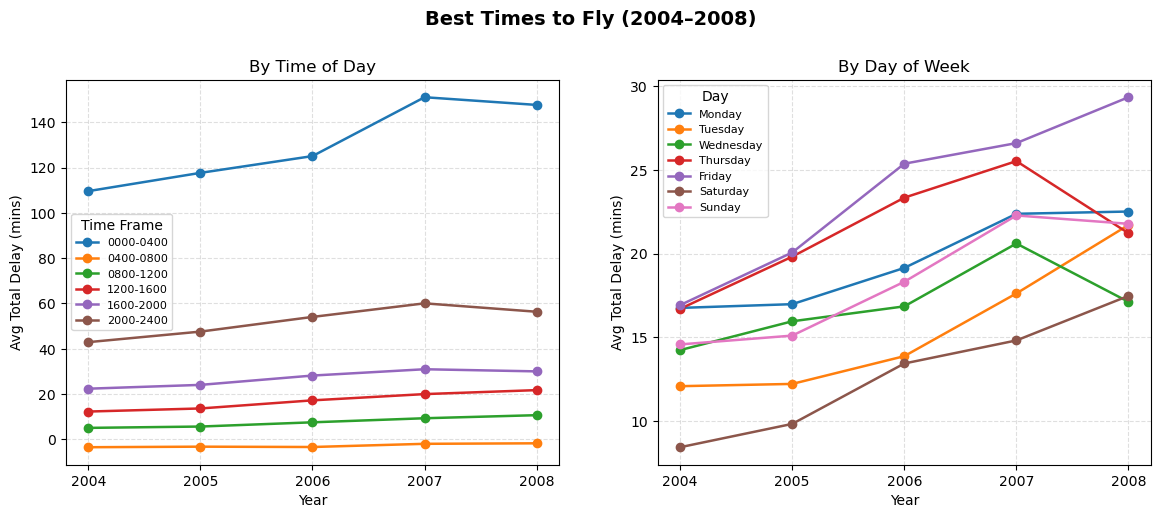

In [23]:
timeframe_order = ["0000-0400","0400-0800","0800-1200",
                   "1200-1600","1600-2000","2000-2400"]
palette_time = sns.color_palette("tab10", n_colors=len(timeframe_order))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Best Times to Fly (2004–2008)", fontsize=14, fontweight="bold", y=1.02)

    # patch1 – By Time of Day
bt_filtered = BestTime[BestTime["TimeFrame"] != "Other"]
for i, tf in enumerate(timeframe_order):
                                        sub = bt_filtered[bt_filtered["TimeFrame"] == tf]
                                        ax1.plot(sub["Year"], sub["AvgDelay"], marker="o",
                                                linewidth=1.8, markersize=6, label=tf, color=palette_time[i])
        
                                        ax1.set_title("By Time of Day")
                                        ax1.set_xlabel("Year")
                                        ax1.set_ylabel("Avg Total Delay (mins)")
                                        ax1.legend(title="Time Frame", fontsize=8)
                                        ax1.grid(True, linestyle="--", alpha=0.4)
                                        ax1.set_xticks([2004, 2005, 2006, 2007, 2008])

# patch2 – By Day Type
for i, day in enumerate(day_order):
                                    sub = BestDay[BestDay["Day"] == day].sort_values("Year")
                                    ax2.plot(sub["Year"], sub["AvgDelay"], marker="o",
                                             linewidth=1.8, markersize=6, label=day, color=palette_day[i])

                                    ax2.set_title("By Day of Week")
                                    ax2.set_xlabel("Year")
                                    ax2.set_ylabel("Avg Total Delay (mins)")
                                    ax2.legend(title="Day", fontsize=8)
                                    ax2.grid(True, linestyle="--", alpha=0.4)
                                    ax2.set_xticks([2004, 2005, 2006, 2007, 2008])


print("Part A plot saved.")


### Conclusion for a)

Best times and Day of the week in 2004 to 2008 to minimise delays are consistently 0400 - 0800 hours and Saturdays.
Even with a fluctuation amongst the other days, Saturdays remained the best day with the lowest average total delays from 2004-2007 and Wednesdays were better in 2008.

## Part 2b) Evaluate whether older planes suffer more delays on a year-to-year basis.

#### Clean plane data
check how many planes are in the data file and how many are valid.

In [27]:
planes_clean = (planes[["tailnum", "year"]]
                .rename(columns = {"tailnum": "TailNum", "year": "ManufactureYear"})
                .copy())
planes_clean["ManufactureYear"] = pd.to_numeric(planes_clean["ManufactureYear"],
                                                errors = "coerce")
planes_clean = planes_clean.dropna(subset = ["ManufactureYear"])
planes_clean = planes_clean[planes_clean["ManufactureYear"] > 1900]

print(f"Total rows: {len(planes)}") # Check how many rows have a valid year
print(f"Rows with valid year: {planes['year'].notna().sum()}")
#print(planes[planes['year'].notna()].head())
print(f"Planes dropped (no year): {planes['year'].isna().sum()}")

Total rows: 5029
Rows with valid year: 4335
Planes dropped (no year): 694


#### Join with cleaned flights
Plane Age is calculated as flight year - manufacture year. This filters out the planes that are pre-1900 and removes data error

In [30]:
flights_age = flights_clean.merge(planes_clean, on = "TailNum", how = "inner")
flights_age["Year"]     = flights_age["Year"].astype(int)
flights_age["PlaneAge"] = flights_age["Year"] - flights_age["ManufactureYear"].astype(int)
flights_age = flights_age[(flights_age["PlaneAge"] >= 0) &
                          (flights_age["PlaneAge"] <= 50)]

#### Plane-Age Brackets
Reduce Noise

In [31]:
def age_bracket(age):
    if age   <= 5:  return "0-5 years"
    elif age <= 10: return "6-10 years"
    elif age <= 20: return "11-20 years"
    elif age <= 30: return "21-30 years"
    else:           return "30+ years"

flights_age['AgeBracket'] = flights_age['PlaneAge'].apply(age_bracket)


In [32]:
age_delay = (flights_age
             .groupby(["Year", "AgeBracket"])["TotalDelay"]
             .mean()
             .reset_index()
             .rename(columns = {"TotalDelay": "AvgDelay"}))

age_order = ["30+ years","21-30 years","11-20 years","6-10 years","0-5 years"]
age_delay["AgeBracket"] = pd.Categorical(age_delay["AgeBracket"],
                                         categories = age_order, 
                                         ordered = True)


#### Pivot for heatmap
required matrix to plot for seaborn heatmap visual


In [33]:
heatmap_data = (age_delay
                .pivot(index="AgeBracket", columns="Year", values="AvgDelay")
                .sort_index())

#### PLOT heatmap

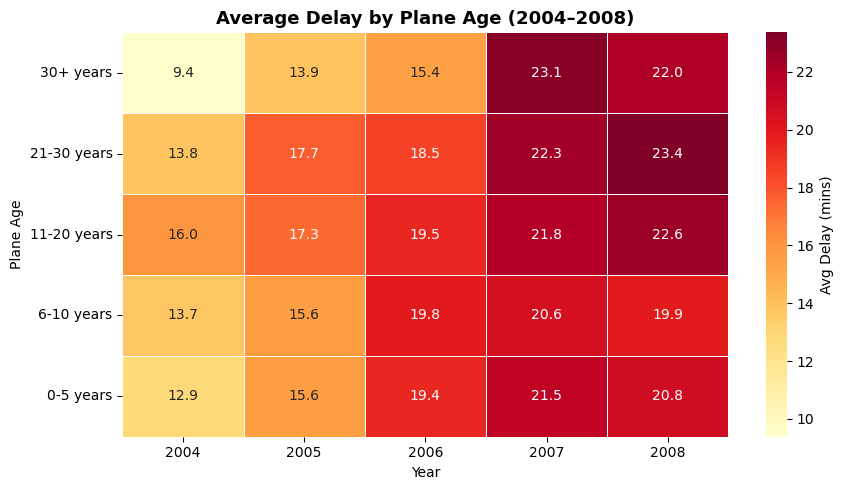

Part B plot saved.


In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_data,
            cmap=sns.color_palette("YlOrRd", as_cmap=True),
            linewidths=0.5,
            linecolor="white",
            annot=True,
            fmt=".1f",
            cbar_kws={"label": "Avg Delay (mins)"},
            ax=ax)

ax.set_title("Average Delay by Plane Age (2004–2008)", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Plane Age")
plt.tight_layout()
plt.savefig("part_b_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Part B plot saved.")

### Conclusion for b)

 - In 2004, the 30+ years row is notably the lightest (lowest delays \~9 mins) - older planes really performed best.

 - By 2007-2008, the 30+ years row becomes the darkest – they declined the most relative to other age groups.

 - As a result, all age groups deteriorate over time (everyone gets darker from left to right), but those over 30 show the most degradation.

## Part 2c) fit a logistic regression model for the probability of diverted US flights using as many features as possible AND Visualize the coefficients across years.



Before fitting the model:

-   Clean airport data
-   Check if coordinates/distance between airports affects diversion (EDA step)
-   Fit 5 separate logistic regression models (one per year)
-   Visualise coefficients across years

In [35]:
# Check raw diverted counts in flights
print(flights['Diverted'].value_counts())

Diverted
0    31187389
1       66831
Name: count, dtype: int64


#### Check EDA and PLOT for distance vs flight diversion
only using 2004 as a sample to gauge for the rest of the years.
EDA is to check if diverted flights tend to have longer/shorter distances?

   Diverted  AvgDistance    Count
0         0   713.231973  7115486
1         1   903.559199    13784


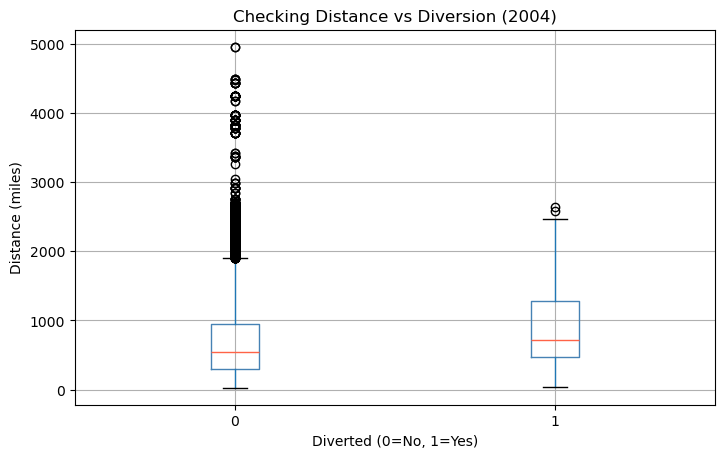

In [41]:
# Load only 2 columns from 2004 for EDA (matching R)
EDA_df = pd.read_csv(("2004.csv"),
                     usecols=['Distance', 'Diverted'])

# Summary table
diversion_check = EDA_df.groupby('Diverted')['Distance'].agg(
                         AvgDistance = 'mean', Count = 'count').reset_index()
print(diversion_check)

# Boxplot on sample of 50000
np.random.seed(123)
flights_sample = EDA_df.sample(50000, random_state = 123)
fig, ax = plt.subplots(figsize = (8, 5))
flights_sample.boxplot(column = 'Distance', by = 'Diverted', ax = ax,
                       boxprops = dict(color = 'steelblue'),
                       medianprops = dict(color = 'tomato'))
ax.set_title("Checking Distance vs Diversion (2004)")
ax.set_xlabel("Diverted (0=No, 1=Yes)")
ax.set_ylabel("Distance (miles)")
plt.suptitle("")
plt.show()

del EDA_df, flights_sample

The vast majority of diverted flights (red, right box) tend to have higher distances than non-diverted flights (blue, left box). The median distance for diverted flights is higher, indicating that longer flights are more likely to be diverted. But, non-diverted flights have way more outlier, hence distance is relevant to include in the logistic regression model.


In [42]:
# Prepare airport coordinate lookups
airports_origin = (airports[["iata", "lat", "long"]]
                   .rename(columns={"iata": "Origin",
                                    "lat": "OriginLat",
                                    "long": "OriginLong"}))
airports_dest   = (airports[["iata", "lat", "long"]]
                   .rename(columns={"iata": "Dest",
                                    "lat": "DestLat",
                                    "long": "DestLong"}))

lr_cols = ["Month", "DayOfWeek", "CRSDepTime", "CRSArrTime",
           "UniqueCarrier", "Origin", "Dest", "Distance", "Diverted"]

numeric_features = ["Month", "DayOfWeek", "CRSDepTime", "CRSArrTime",
                    "Distance", "OriginLat", "OriginLong", "DestLat", "DestLong"]

coef_records = []

Due to memory limit causing the codes to not run, i processed the data year by year so it wipes each year's data before loading the next one.

- To join coordinates with actual latitude and longtitude from each airport
- Numeric deatures are scaled to be allow coefficients to be compared
- Ensure samples are balanced
- Dummies used to convert the UniqueCarriers to binary codes to be used for logistic regression
- UniqueCarriers information is needed to accurately fit model
  (they are a factor but no need to include into the visual plot; noise)
- Extract only non-carrier coefficients for visual

In [52]:
for yr in range(2004, 2009):
    print(f"Fitting model for {yr} ...")
    df = pd.read_csv((f"{yr}.csv"),
                     usecols=lr_cols, na_values = ["NA", ""])

    # Join coordinates
    df = (df.merge(airports_origin, on = "Origin", how = "left")
            .merge(airports_dest,   on = "Dest",   how = "left"))

    df = df.dropna(subset = ["OriginLat", "DestLat", "Distance",
                            "CRSDepTime", "CRSArrTime"])
    df["Diverted"] = df["Diverted"].astype(int)

    # Scale numeric features
    
    scaler = StandardScaler()
    df[numeric_features] = scaler.fit_transform(df[numeric_features])

    # Balanced sample: 5 000 diverted + 5 000 not-diverted
    div0 = df[df["Diverted"] == 0].sample(n = 5000, random_state = 123)
    div1 = df[df["Diverted"] == 1].sample(n = 5000, random_state = 123)
    df_sample = pd.concat([div0, div1]).reset_index(drop = True)
    
    df_encoded = pd.get_dummies(df_sample, columns = ["UniqueCarrier"],
                                drop_first = True, dtype = float)

    feature_cols = [c for c in df_encoded.columns
                    if c not in ["Diverted", "Origin", "Dest"]]
    X = df_encoded[feature_cols].values
    y = df_encoded["Diverted"].values

    model = LogisticRegression(max_iter = 1000, solver = "lbfgs", random_state = 123)
    model.fit(X, y)

    # Store non-carrier coefficients
    for name, coef in zip(feature_cols, model.coef_[0]):
        if not name.startswith("UniqueCarrier"):
               coef_records.append({"Year": yr, "term": name, "estimate": coef})

    del df, df_sample, df_encoded
    print(f"Done: {yr}")

print("all models fitted")

Fitting model for 2004 ...
Done: 2004
Fitting model for 2005 ...
Done: 2005
Fitting model for 2006 ...
Done: 2006
Fitting model for 2007 ...
Done: 2007
Fitting model for 2008 ...
Done: 2008
all models fitted


#### Coefficient dataframe

In [66]:
coef_df = pd.DataFrame(coef_records)
print(coef_df)

     Year        term  estimate
0    2004       Month  0.058978
1    2004   DayOfWeek -0.005271
2    2004  CRSDepTime -0.080205
3    2004  CRSArrTime  0.170946
4    2004    Distance  0.399313
..    ...         ...       ...
130  2008    Distance  0.402731
131  2008   OriginLat  0.059051
132  2008  OriginLong  0.142100
133  2008     DestLat  0.082803
134  2008    DestLong  0.055528

[135 rows x 3 columns]


#### PLOT coefficient across years line graph

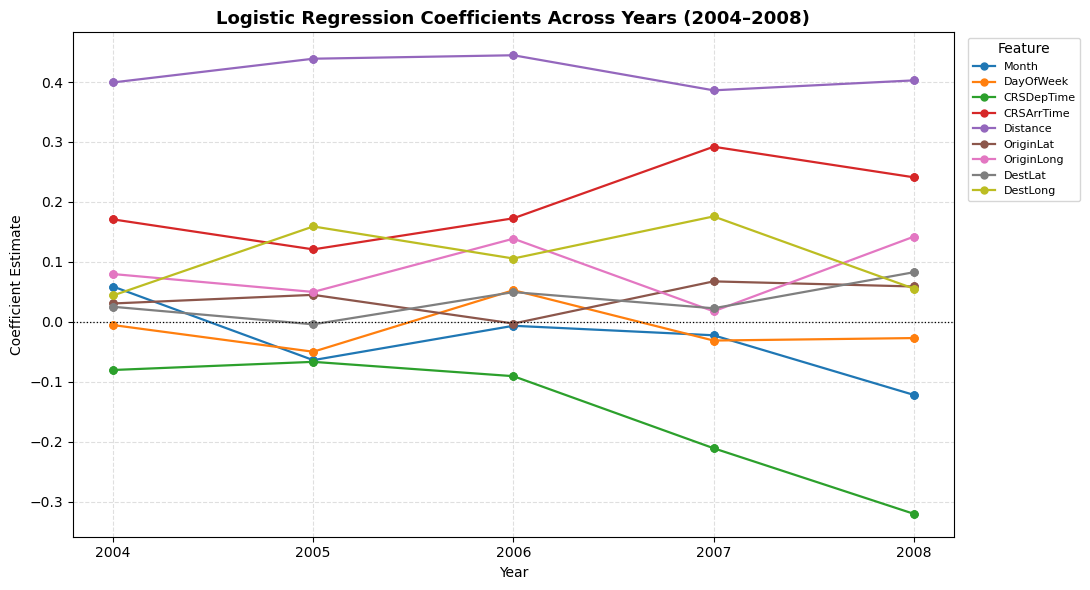

Part C plot saved.


In [67]:
terms = coef_df["term"].unique()
palette_c = sns.color_palette("tab10", n_colors = len(terms))

fig, ax = plt.subplots(figsize = (11, 6))
for i, term in enumerate(terms):
    sub = coef_df[coef_df["term"] == term].sort_values("Year")
    ax.plot(sub["Year"], sub["estimate"], marker = "o",
            linewidth = 1.6, markersize = 5, label = term, color = palette_c[i])

ax.axhline(0, linestyle = "dotted", color = "black", linewidth = 0.9)
ax.set_title("Logistic Regression Coefficients Across Years (2004–2008)",
             fontsize = 13, fontweight = "bold")
ax.set_xlabel("Year")
ax.set_ylabel("Coefficient Estimate")
ax.legend(title = "Feature", fontsize = 8, 
          bbox_to_anchor = (1.01, 1), loc = "upper left")
ax.set_xticks([2004, 2005, 2006, 2007, 2008])
ax.grid(True, linestyle = "--", alpha = 0.4)
plt.tight_layout()
plt.savefig("part_c_logreg_linegraph.png", dpi = 150, bbox_inches = "tight")
plt.show()

print("Part C plot saved.")

### Conclusion for c)

Distance is found to be consistently the strongest positive predictor, meaning that longer flights have higher diversion probability.

CRS Departure Time shows a decreasing effect over time meaning scheduled departure has lower diversion probability.

CRS Arrival Time has a consistent positive with a peak in 2007 which indicates that scheduling arrival time have higher diversion probability.

Month representts seasonal effects, as it slowly depletes overtime, it can be interpreted as airlines having better weather contingency plannings.

The Destination Latitude and Longitude makes perfect sense too as flights in the north or south tend to face more weather disruptions and flights heading further west may have higher diversion due to rocky and mountainous terrain.
